In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
class BrainTumourDataset(Dataset):
    def __init__(self,root_dir):
        self.samples = []
        
        img_root = os.path.join(root_dir,"image")
        mask_root = os.path.join(root_dir,"mask")
        
        for cls in os.listdir(img_root):
            img_dir = os.path.join(img_root,cls)
            mask_dir = os.path.join(mask_root,cls)
            
            if not os.path.isdir(img_dir) or not os.path.isdir(mask_dir):
                continue
            
            for img_name in os.listdir(img_dir):
                img_path = os.path.join(img_dir,img_name)
                
                name,ext = os.path.splitext(img_name)
                mask_name = name + "_mask" + ext
                
                mask_path = os.path.join(mask_dir,mask_name)
                
                if os.path.exists(mask_path):
                    self.samples.append((img_path,mask_path))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self,idx):
        img_path, mask_path = self.samples[idx]
        
        img = cv2.imread(img_path,0)
        mask = cv2.imread(mask_path,0)
        
        if img is None or mask is None:
            return self.__getitem__((idx+1)%len(self.samples))
        
        image = cv2.resize(img,(256,256))
        mask = cv2.resize(mask,(256,256))
        
        image = image/255.0
        mask = mask/255.0
        
        image = torch.tensor(image,dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask,dtype=torch.float32).unsqueeze(0)
        
        return image,mask

In [3]:
train_dataset = BrainTumourDataset("./brain_tumor/Dataset/segmentation_data/train")
val_dataset  = BrainTumourDataset("./brain_tumor/Dataset/segmentation_data/val")

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False)

In [4]:
print(train_dataset[0][0].shape,train_dataset[0][1].shape)

torch.Size([1, 256, 256]) torch.Size([1, 256, 256])


In [5]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        
        def block(in_c,out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,3,padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c,out_c,3,padding=1),
                nn.ReLU()
            )
        
        self.enc1 = block(1,64)
        self.enc2 = block(64,128)
        self.enc3 = block(128,256)
        
        self.pool = nn.MaxPool2d(2)
        
        self.bottleneck = block(256,512)
        
        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.dec3 = block(512,256)
        
        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.dec2 = block(256,128)
        
        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.dec1 = block(128,64)
        
        self.final = nn.Conv2d(64,1,1)
        
    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        
        b = self.bottleneck(self.pool(e3))
        
        d3 = self.up3(b)
        d3 = torch.cat([d3,e3],dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2,e2],dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1,e1],dim=1)
        d1 = self.dec1(d1)
        
        out = self.final(d1)
        
        return torch.sigmoid(out)

In [6]:
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return 1 - dice

bce_loss = nn.BCELoss()

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Model().to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [8]:
from tqdm import tqdm

In [ ]:
epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    for images,masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        masks = masks.to(device)
        
        preds = model(images)
        
        loss = bce_loss(preds,masks) + dice_loss(preds,masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader)}")

Epoch 1/20: 100%|██████████| 268/268 [1:25:03<00:00, 19.04s/it]


Epoch 1/20, Loss: 1.0833583947882723


Epoch 2/20: 100%|██████████| 268/268 [1:09:10<00:00, 15.49s/it]


Epoch 2/20, Loss: 0.9120743679466532


Epoch 3/20: 100%|██████████| 268/268 [1:07:04<00:00, 15.02s/it]


...

Epoch 18/20, Loss: 0.2638663685143883


Epoch 19/20: 100%|██████████| 268/268 [1:40:16<00:00, 22.45s/it]


Epoch 19/20, Loss: 0.24997354977166475


Epoch 20/20: 100%|██████████| 268/268 [1:39:04<00:00, 22.18s/it]

Epoch 20/20, Loss: 0.2273260134258377


In [10]:
torch.save(model.state_dict(),"segmentation_model.pth")

In [11]:
torch.save(model,"full_segmentation_model.pth")

In [12]:
torch.jit.script(model).save("scripted_segmentation_model.pt")

In [13]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss
},"checkpoint.pth")

In [14]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(model,f)

In [15]:
import joblib
joblib.dump(model, "model.joblib")

['model.joblib']

In [16]:
model.eval()
val_loss = 0

with torch.no_grad():
    for images, masks in tqdm(val_loader,desc="validation"):
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = bce_loss(preds, masks) + dice_loss(preds, masks)

        val_loss += loss.item()

print("Validation Loss:", val_loss / len(val_loader))

validation: 100%|██████████| 39/39 [04:28<00:00,  6.88s/it]

Validation Loss: 0.31165287433526456


In [17]:
test_dataset = BrainTumourDataset("./brain_tumor/Dataset/segmentation_data/test")
test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False)

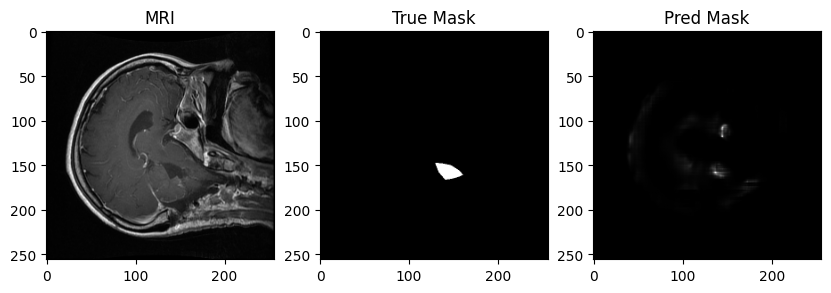

In [18]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    preds = model(images)

preds = preds.cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("MRI")
plt.imshow(images[0][0].cpu(), cmap="gray")

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(masks[0][0], cmap="gray")

plt.subplot(1,3,3)
plt.title("Pred Mask")
plt.imshow(preds[0][0], cmap="gray")

plt.show()